In [1]:
pip install yfinance pandas

In [2]:
import yfinance as yf

ticker = yf.Ticker("GC=F")

df = ticker.history(start="2025-09-02", end="2026-09-02", interval="1d", auto_adjust=False)

df = df.drop(columns=['Dividends', 'Stock Splits'], errors='ignore')

df_display = df.reset_index()

display(df_display)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2025-09-02 00:00:00-04:00,3485.699951,3559.199951,3485.699951,3549.399902,3549.399902,658
1,2025-09-03 00:00:00-04:00,3554.800049,3593.699951,3553.199951,3593.199951,3593.199951,72
2,2025-09-04 00:00:00-04:00,3549.899902,3573.600098,3549.899902,3565.800049,3565.800049,237
3,2025-09-05 00:00:00-04:00,3567.800049,3613.199951,3567.800049,3613.199951,3613.199951,925
4,2025-09-08 00:00:00-04:00,3594.500000,3641.000000,3590.000000,3638.100098,3638.100098,97
...,...,...,...,...,...,...,...
247,2026-08-26 00:00:00-04:00,4615.299805,4615.299805,4598.200195,4598.200195,4598.200195,1051
248,2026-08-27 00:00:00-04:00,4609.700195,4609.700195,4609.700195,4609.700195,4609.700195,5558
249,2026-08-28 00:00:00-04:00,4599.299805,4625.500000,4451.799805,4478.100098,4478.100098,1758
250,2026-08-31 00:00:00-04:00,4430.000000,4466.899902,4410.899902,4431.100098,4431.100098,360


In [3]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

def prepare_data_multivariate(df, features, target_col, window_len=30, test_size=0.2):
    scaler_x = MinMaxScaler(feature_range=(0, 1))
    scaler_y = MinMaxScaler(feature_range=(0, 1))

    x_data = scaler_x.fit_transform(df[features].values)
    y_data = scaler_y.fit_transform(df[[target_col]].values)

    split_row = len(df) - int(test_size * len(df))

    X, y = [], []
    for i in range(len(df) - window_len):
        X.append(x_data[i:(i + window_len), :])
        y.append(y_data[i + window_len, 0])

    X, y = np.array(X), np.array(y)
    X_train = X[:split_row - window_len]
    y_train = y[:split_row - window_len]
    X_test = X[split_row - window_len:]
    y_test = y[split_row - window_len:]

    return X_train, X_test, y_train, y_test, scaler_y, scaler_x

pure_features = ['Open', 'High', 'Low', 'Close', 'Volume']

X_train, X_test, y_train, y_test, scaler_y, scaler_x = prepare_data_multivariate(
    df[pure_features], pure_features, 'Close', window_len=30
)

print(f"Success! Pure data structures: X_train shape: {X_train.shape}")
print(f"Columns currently in use: {pure_features}")

Success! Pure data structures: X_train shape: (172, 30, 5)
Columns currently in use: ['Open', 'High', 'Low', 'Close', 'Volume']


In [4]:
def train_test_split(df, test_size=0.2):
    split_row = len(df) - int(test_size * len(df))
    train_data = df.iloc[:split_row]
    test_data = df.iloc[split_row:]
    return train_data, test_data

In [5]:
def line_plot(line1, line2, label1=None, label2=None, title='', lw=2):
    fig, ax = plt.subplots(1, figsize=(13, 7))
    ax.plot(line1, label=label1, linewidth=lw)
    ax.plot(line2, label=label2, linewidth=lw)
    ax.set_ylabel('price [USD]', fontsize=14)
    ax.set_title(title, fontsize=16)
    ax.legend(loc='best', fontsize=16);

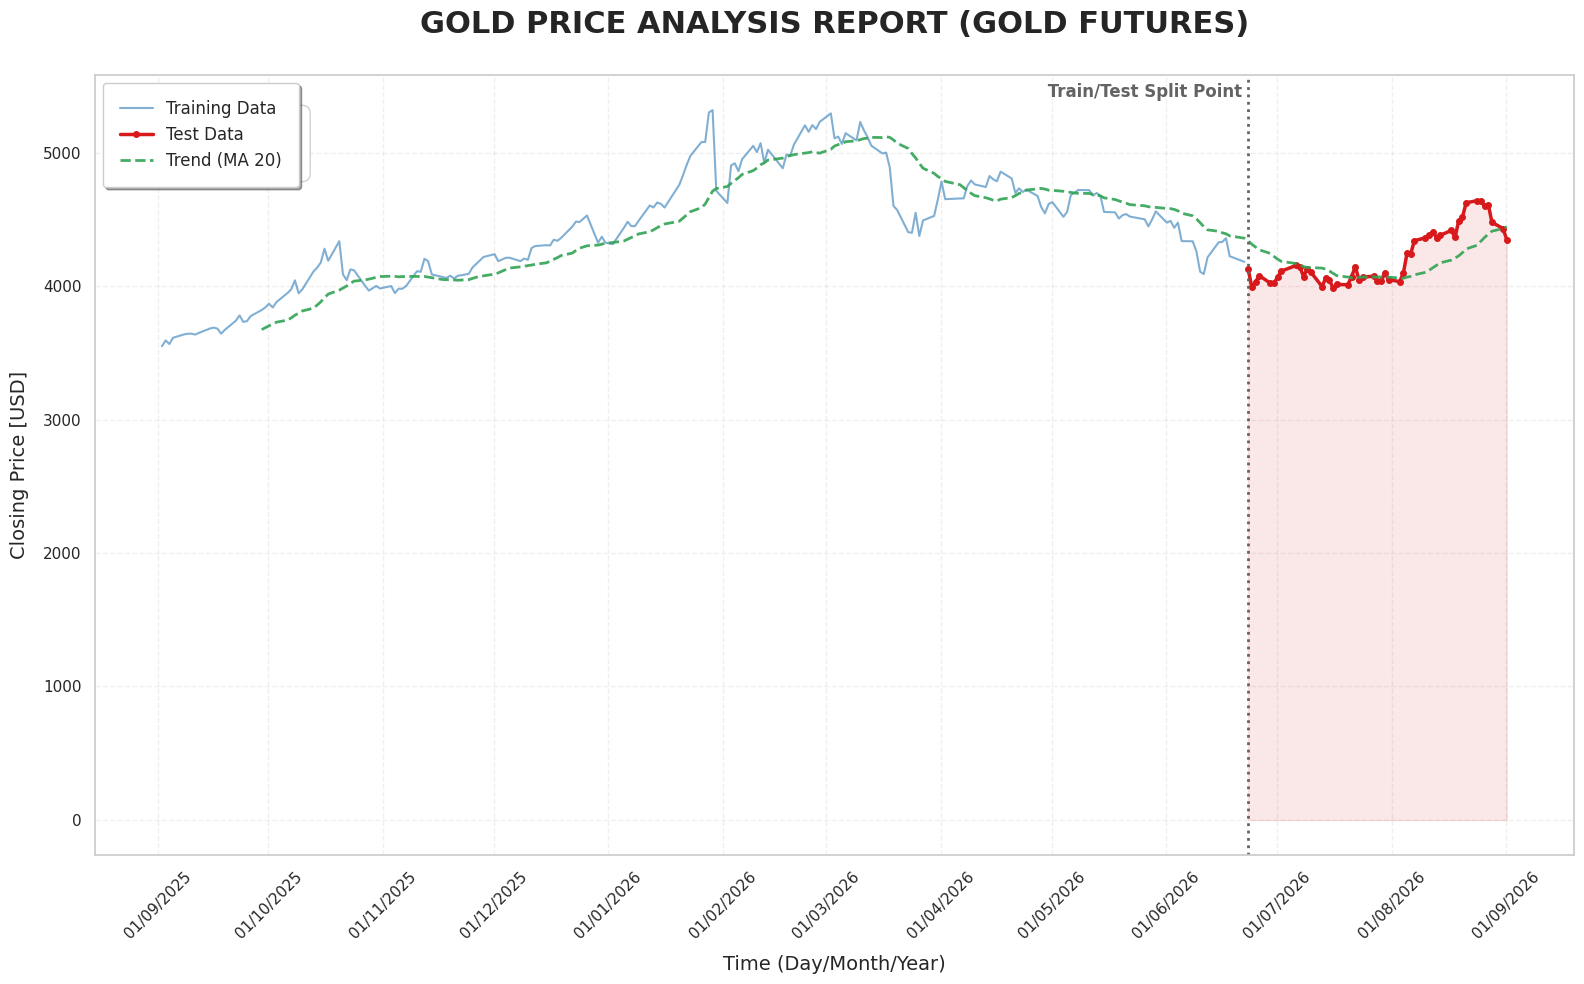

In [6]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# 1. Calculate MA20 trend
df['MA20'] = df['Close'].rolling(window=20).mean()

# Ensure train and test sets are defined based on earlier splits
split_row = len(df) - int(0.2 * len(df))
train = df.iloc[:split_row]
test = df.iloc[split_row:]

# 2. Set professional plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.figure(figsize=(16, 10))

# 3. Plot Training and Test data
plt.plot(train.index, train['Close'], label='Training Data', color='#2c7bb6', linewidth=1.5, alpha=0.6)
plt.plot(test.index, test['Close'], label='Test Data', color='#d7191c', linewidth=2.5, marker='o', markersize=4)

# 4. Plot Moving Average trend
plt.plot(df.index, df['MA20'], label='Trend (MA 20)', color='#31a354', linestyle='--', linewidth=2, alpha=0.9)

# 5. Highlight Test data area
plt.fill_between(test.index, test['Close'], color='#d7191c', alpha=0.1)

# 6. Add split boundary line
split_date = test.index[0]
plt.axvline(x=split_date, color='#636363', linestyle=':', linewidth=2)
plt.text(split_date, plt.ylim()[1]*0.97, ' Train/Test Split Point ', color='#636363', fontweight='bold', ha='right', fontsize=12)

# 7. Format time axis
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=45, fontsize=11)
plt.yticks(fontsize=11)

# 8. Title and labels
plt.title('GOLD PRICE ANALYSIS REPORT (GOLD FUTURES)', fontsize=22, fontweight='bold', color='#252525', pad=30)
plt.xlabel('Time (Day/Month/Year)', fontsize=14, labelpad=10)
plt.ylabel('Closing Price [USD]', fontsize=14, labelpad=10)

# 9. Add summary annotation box
stats_box = f"TOTAL SAMPLES: {len(df)}\nTraining: {len(train)}\nTesting: {len(test)}"
plt.gca().text(0.02, 0.95, stats_box, transform=plt.gca().transAxes, fontsize=12,
            verticalalignment='top', fontweight='500',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#cccccc', alpha=0.9))

# 10. Legend and grid
plt.legend(loc='upper left', fontsize=12, frameon=True, shadow=True, fancybox=True, borderpad=1)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from sklearn.metrics import mean_squared_error

tf.keras.backend.clear_session()

model_pure = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(80, return_sequences=True),
    Dropout(0.2),
    LSTM(40),
    Dropout(0.2),
    Dense(16),
    Dense(1)
])

model_pure.compile(optimizer='adam', loss='mse')

print("Starting pure model training...")
history_pure = model_pure.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=0
)

preds_pure = model_pure.predict(X_test, verbose=0)
y_test_actual = scaler_y.inverse_transform(y_test.reshape(-1, 1)).squeeze()
preds_actual = scaler_y.inverse_transform(preds_pure).squeeze()

rmse_pure = np.sqrt(mean_squared_error(y_test_actual, preds_actual))
print(f"\n--- PURE MODEL RESULTS ---")
print(f"RMSE: {rmse_pure:.2f} USD")

Starting pure model training...

--- PURE MODEL RESULTS ---
RMSE: 107.90 USD


In [ ]:
import tensorflow as tf
import numpy as np
import joblib
import os
from google.colab import drive
from tensorflow.keras.models import Sequential

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# Define target directory
target_dir = '/content/drive/MyDrive/CH LSTM'
if not os.path.exists(target_dir):
    os.makedirs(target_dir)
    print(f"Created directory: {target_dir}")

# Ensure data is ready (re-run preparation if needed)
features = ['Open', 'High', 'Low', 'Close', 'Volume']
target_col = 'Close'
X_train, X_test, y_train, y_test, scaler_y, scaler_x = prepare_data_multivariate(
    df, features, target_col, window_len=30, test_size=0.2
)

tf.keras.backend.clear_session()
tf.random.set_seed(42)

model_final = Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1], X_train.shape[2])),
    tf.keras.layers.LSTM(64, return_sequences=False),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1)
])

model_final.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')

print("Training Model...")
model_final.fit(
    X_train, y_train,
    epochs=50,
    batch_size=8,
    validation_data=(X_test, y_test),
    verbose=0
)

# Save model and both scalers to Google Drive
model_path = os.path.join(target_dir, 'LSTM_Model.keras')
scaler_y_path = os.path.join(target_dir, 'scaler_final.pkl')
scaler_x_path = os.path.join(target_dir, 'lstm_scaler_x.pkl')

model_final.save(model_path)
joblib.dump(scaler_y, scaler_y_path)
joblib.dump(scaler_x, scaler_x_path)

print(f"Success! Model and scalers saved to: {target_dir}")

Mounted at /content/drive
Training Model...
Success! Model and scaler saved to: /content/drive/MyDrive/CH LSTM


In [9]:
train, test = train_test_split(df, test_size=0.2)

In [10]:
np.random.seed(42)
window_len = 30
test_size = 0.2
zero_base = True
lstm_neurons = 50
epochs = 50
batch_size = 30
loss = 'mse'
dropout = 0.2
optimizer = 'adam'

In [11]:
features = ['Open', 'High', 'Low', 'Close', 'Volume']
target_col = 'Close'


X_train, X_test, y_train, y_test, scaler_y, scaler_x = prepare_data_multivariate(
    df, features, target_col, window_len=30, test_size=0.2
)

print(f"The data is ready.: X_train {X_train.shape}, y_train {y_train.shape}")

The data is ready.: X_train (172, 30, 5), y_train (172,)


In [12]:
model_final.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,933 (222.40 KB)

 Trainable params: 18,977 (74.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 37,956 (148.27 KB)

Epoch 1/50


<>:46: SyntaxWarning: invalid escape sequence '\S'
<>:46: SyntaxWarning: invalid escape sequence '\S'
/tmp/ipykernel_5418/1728186044.py:46: SyntaxWarning: invalid escape sequence '\S'
  print(f"\Subsequent successful results {epochs} epochs:")
/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - loss: 0.1458 - val_loss: 0.0372
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0505 - val_loss: 0.0061
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0164 - val_loss: 0.0080
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0190 - val_loss: 0.0052
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0102 - val_loss: 0.0078
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0130 - val_loss: 0.0062
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0095 - val_loss: 0.0050
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0112 - val_loss: 0.0048
Epoch 9/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0124 - val_loss: 0.0051
Epoch 10/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0105 - val_loss: 0.0056
Epoch 11/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0102 - val_loss: 0.0052
Epoch 12/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0095 - val_loss: 0.0044
Epoch 13/50


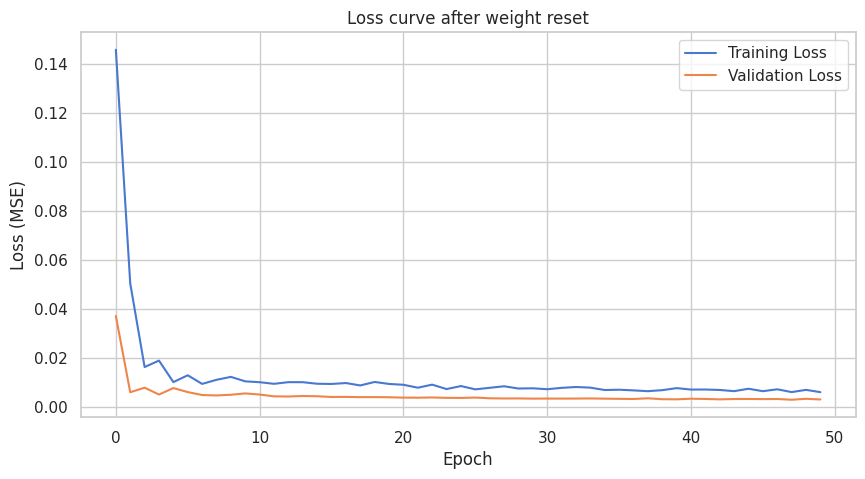

In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Activation, Dense, LSTM, Dropout
import numpy as np
import matplotlib.pyplot as plt


def build_lstm_model(input_data, output_size, neurons=100, activ_func='linear',
                     dropout=0.2, loss='mse', optimizer='adam'):
    model = Sequential()
    model.add(LSTM(neurons, input_shape=(input_data.shape[1], input_data.shape[2])))
    model.add(Dropout(dropout))
    model.add(Dense(units=output_size))
    model.add(Activation(activ_func))
    model.compile(loss=loss, optimizer=optimizer)
    return model

tf.keras.backend.clear_session()

model = build_lstm_model(
    input_data=X_train,
    output_size=1,
    neurons=100,
    dropout=0.2,
    loss='mse',
    optimizer='adam'
)

epochs = 50
batch_size = 32

history = model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_test, y_test),
    verbose=1,
    shuffle=True
)


if 'loss' in history.history and not np.isnan(history.history['loss'][-1]):
    final_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]
    print(f"\Subsequent successful results {epochs} epochs:")
    print(f"- Loss (Training): {final_loss:.6f}")
    print(f"- Val Loss: {final_val_loss:.6f}")

    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss curve after weight reset')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("The NaN error is still occurring. The data normalization function needs to be re-checked.")

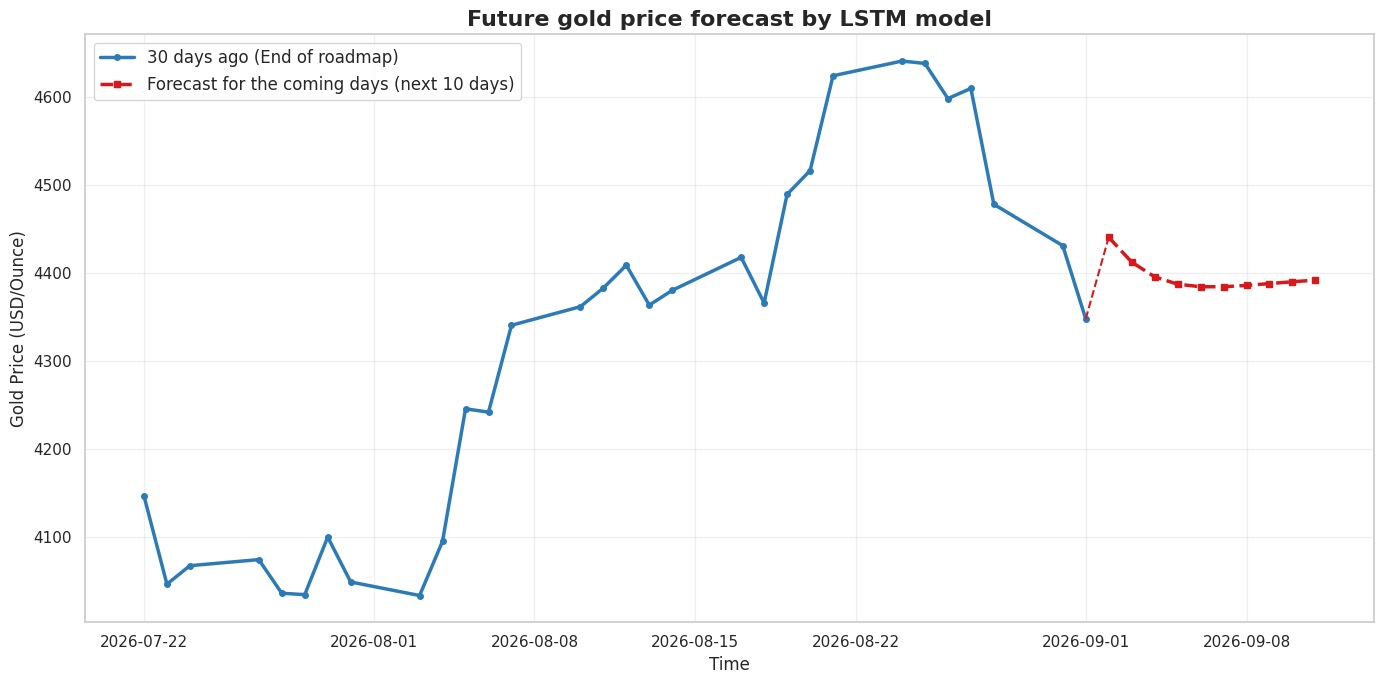

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import tensorflow as tf

def generate_forecast_chart(model, df, features, scaler_x, scaler_y, window_len=30, forecast_steps=10):

    hist_data = df[features].tail(window_len).copy()
    last_date = df.index[-1]

    forecast_values = []
    forecast_dates = []
    current_window = hist_data.values.copy()
    close_idx = features.index('Close')

    for i in range(forecast_steps):
        input_scaled = scaler_x.transform(current_window).reshape(1, window_len, len(features))
        pred_scaled = model.predict(input_scaled, verbose=0)
        pred_val = scaler_y.inverse_transform(pred_scaled).item()

        forecast_values.append(pred_val)

        next_date = last_date + pd.Timedelta(days=i+1)
        forecast_dates.append(next_date)

        new_row = current_window[-1].copy()
        new_row[close_idx] = pred_val
        current_window = np.vstack([current_window[1:], new_row])

    plt.figure(figsize=(14, 7))

    plt.plot(df.index[-30:], df['Close'].tail(30), color='#2c7bb6', label='30 days ago (End of roadmap)', linewidth=2.5, marker='o', markersize=4)

    plt.plot(forecast_dates, forecast_values, color='#d7191c', label='Forecast for the coming days (next 10 days)', linewidth=2.5, linestyle='--', marker='s', markersize=4)

    plt.plot([last_date, forecast_dates[0]], [df['Close'].iloc[-1], forecast_values[0]], color='#d7191c', linestyle='--')

    plt.title(f'Future gold price forecast by LSTM model', fontsize=16, fontweight='bold')
    plt.xlabel('Time', fontsize=12)
    plt.ylabel('Gold Price (USD/Ounce)', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


generate_forecast_chart(model_final, df, pure_features, scaler_x, scaler_y)